# Final Robustness: Utility, Candidate Pool, and Forecaster-Specific Source Reliance

This section implements robustness and reliability checks for predictive utility and functional reliance under the fixed protocols reported in the paper.


In [1]:
from pathlib import Path
from types import SimpleNamespace

import gc
import importlib
import math
import random
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore")

SEED = 2026
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEQ_LEN = 96
LABEL_LEN = 48
ALL_HORIZONS = [96, 192, 336, 720]

CONDITIONS = [
    ("Electricity", 192),
    ("Solar", 720),
    ("ETTh1", 720),
]

MAX_TOPK = 10
RAW_CORR_TOPM = 8
TEACHER_CONSENSUS_TOPM = 12
RANDOM_SOURCE_COUNT = 10

MAX_TARGETS_HIGH_DIM = 6
MAX_TRAIN_ORIGINS = 5000
MAX_TEST_WINDOWS = 512

PERTURB_SEEDS = [2026, 2027, 2028, 2029, 2030]
MLP_TRAIN_SEEDS = [2026, 2027, 2028]

RIDGE_LAMBDA = 1e-3
SOURCE_RIDGE_LAMBDA = 1e-2
FORECAST_RIDGE_LAMBDA = 1e-2

MLP_HIDDEN = 128
MLP_EPOCHS = 30
MLP_PATIENCE = 5
MLP_LR = 1e-3
MLP_WEIGHT_DECAY = 1e-4
MLP_BATCH_SIZE = 256

RANK_K = 5

PROJECT_ROOT = Path("/data/code/2026_08")
BASELINE_ROOT = PROJECT_ROOT / "results_external_baselines_phase1_direct"

TEACHER_CACHE_ROOT = (
    PROJECT_ROOT
    / "results_itransformer_explicit_sparse_horizon_mask"
    / "predictive_teacher_hardmask_cache"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "results_final_robustness_forecaster_specific_reliance"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("Output:", OUTPUT_DIR)


PyTorch: 2.4.1+cu121
Device: cuda
GPU: NVIDIA A100-SXM4-80GB
Output: /data/code/2026_08/results_final_robustness_forecaster_specific_reliance


## 1. Determinism, ranking metrics, and selection rules


In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

def effective_topk(C):
    return int(max(1, min(MAX_TOPK, math.ceil((C - 1) / 2))))

def choose_targets(dataset_name, C):
    if C <= 10:
        return np.arange(C, dtype=np.int64)
    return np.unique(
        np.linspace(
            0,
            C - 1,
            min(MAX_TARGETS_HIGH_DIM, C),
            dtype=np.int64,
        )
    )

def choose_batch_size(dataset_name, H):
    if dataset_name == "Electricity":
        return 8
    if dataset_name == "Solar":
        return 16
    return 32

def evenly_subsample(arr, max_n):
    arr = np.asarray(arr)
    if len(arr) <= max_n:
        return arr
    idx = np.unique(
        np.linspace(0, len(arr) - 1, max_n, dtype=np.int64)
    )
    return arr[idx]

def safe_spearman(a, b):
    s = (
        pd.DataFrame({"a": a, "b": b})
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )
    if len(s) < 3:
        return np.nan
    if s["a"].nunique() < 2 or s["b"].nunique() < 2:
        return np.nan
    return float(s.corr(method="spearman").iloc[0, 1])

def topk_ids(scores, ids, k):
    scores = np.asarray(scores, dtype=np.float64)
    ids = np.asarray(ids, dtype=np.int64)
    order = np.argsort(scores)[::-1][:k]
    return set(ids[order].tolist())

def topk_jaccard(a, b, ids, k):
    A = topk_ids(a, ids, k)
    B = topk_ids(b, ids, k)
    return len(A & B) / max(1, len(A | B))

def ndcg_at_k(rank_scores, relevance_scores, k):
    rank_scores = np.asarray(rank_scores, dtype=np.float64)
    rel = np.maximum(
        np.asarray(relevance_scores, dtype=np.float64),
        0.0,
    )

    if np.all(rel <= 0):
        return np.nan

    order = np.argsort(rank_scores)[::-1][:k]
    ideal = np.argsort(rel)[::-1][:k]

    def dcg(sel):
        vals = rel[sel]
        discount = 1.0 / np.log2(np.arange(2, 2 + len(vals)))
        return float(np.sum(vals * discount))

    denom = dcg(ideal)
    return np.nan if denom <= 0 else dcg(order) / denom


## 2. Time-Series-Library and datasets


In [3]:
TSLIB_CANDIDATES = [
    Path("/data/Time-Series-Library"),
    Path("/data/Time-Series-Library_v2"),
    Path("/data/Time-Series-Library"),
]

TSL_ROOT = next(
    (
        p.resolve()
        for p in TSLIB_CANDIDATES
        if (p / "models" / "iTransformer.py").exists()
    ),
    None,
)

if TSL_ROOT is None:
    raise FileNotFoundError("Time-Series-Library source not found.")

if str(TSL_ROOT) not in sys.path:
    sys.path.insert(0, str(TSL_ROOT))

iTransformer_module = importlib.import_module("models.iTransformer")

DATASET_CANDIDATES = {
    "Electricity": [
        "/data/dataset/electricity/electricity.csv",
        "/data/dataset/ECL/electricity.csv",
        "/data/dataset/electricity.csv",
    ],
    "Solar": [
        "/data/dataset/solar/solar_AL.txt",
        "/data/dataset/Solar/solar_AL.txt",
        "/data/dataset/solar_AL.txt",
    ],
    "ETTh1": [
        "/data/dataset/ETT-small/ETTh1.csv",
        "/data/dataset/ETTh1.csv",
    ],
}

DATASET_SPECS = {
    "Electricity": {"channels": 321, "freq": "h"},
    "Solar": {"channels": 137, "freq": "h"},
    "ETTh1": {"channels": 7, "freq": "h"},
}

def resolve_path(candidates):
    for p in candidates:
        p = Path(p)
        if p.exists():
            return p.resolve()
    return None

DATASET_FILES = {}

for d, candidates in DATASET_CANDIDATES.items():
    path = resolve_path(candidates)
    if path is None:
        raise FileNotFoundError(f"{d}: dataset file not found.")
    DATASET_FILES[d] = path
    print(f"{d:12s} -> {path}")

print("TSLib:", TSL_ROOT)


Electricity  -> /data/dataset/electricity/electricity.csv
Solar        -> /data/dataset/solar/solar_AL.txt
ETTh1        -> /data/dataset/ETT-small/ETTh1.csv
TSLib: /data/Time-Series-Library


## 3. Dataset loading and temporal windows


In [4]:
def load_numeric_series(dataset_name, path):
    path = Path(path)

    if path.suffix.lower() == ".csv":
        df = pd.read_csv(path)

        date_col = None
        for candidate in ["date", "datetime", "timestamp", "time"]:
            if candidate in df.columns:
                date_col = candidate
                break

        if date_col is None:
            first = df.columns[0]
            if not pd.api.types.is_numeric_dtype(df[first]):
                date_col = first

        if date_col is not None:
            df = df.drop(columns=[date_col])

        df = df.select_dtypes(include=[np.number])
        x = df.to_numpy(dtype=np.float32)

    else:
        try:
            x = np.loadtxt(path, delimiter=",", dtype=np.float32)
        except Exception:
            x = np.loadtxt(path, dtype=np.float32)

        if x.ndim == 1:
            x = x[:, None]

    if x.ndim != 2:
        raise ValueError(f"{dataset_name}: expected [T,C], got {x.shape}")
    if not np.isfinite(x).all():
        raise ValueError(f"{dataset_name}: non-finite values")

    return x

def split_boundaries(dataset_name, T):
    if dataset_name == "ETTh1":
        train_end = 12 * 30 * 24
        val_end = train_end + 4 * 30 * 24
        test_end = val_end + 4 * 30 * 24
        return (
            min(train_end, T),
            min(val_end, T),
            min(test_end, T),
        )

    return int(0.70 * T), int(0.80 * T), T

def load_and_normalize(dataset_name):
    raw = load_numeric_series(
        dataset_name,
        DATASET_FILES[dataset_name],
    )

    T, C = raw.shape
    train_end, val_end, test_end = split_boundaries(
        dataset_name,
        T,
    )

    mean = raw[:train_end].mean(axis=0, keepdims=True)
    std = np.maximum(
        raw[:train_end].std(axis=0, keepdims=True),
        1e-6,
    )

    x = (raw - mean) / std

    return x.astype(np.float32), {
        "T": T,
        "C": C,
        "train_end": train_end,
        "val_end": val_end,
        "test_end": test_end,
    }

def common_train_origins(train_end):
    last = int(train_end) - max(ALL_HORIZONS)

    origins = np.arange(
        SEQ_LEN,
        last + 1,
        dtype=np.int64,
    )

    return evenly_subsample(
        origins,
        MAX_TRAIN_ORIGINS,
    )

def selected_test_origins(meta, H):
    origins = np.arange(
        max(SEQ_LEN, int(meta["val_end"])),
        int(meta["test_end"]) - H + 1,
        dtype=np.int64,
    )

    return evenly_subsample(
        origins,
        MAX_TEST_WINDOWS,
    )

def summary_features_at_origins(x, origins):
    origins = np.asarray(origins, dtype=np.int64)

    last = x[origins - 1]

    mean3 = np.stack(
        [x[t-3:t].mean(axis=0) for t in origins],
        axis=0,
    )

    mean12 = np.stack(
        [x[t-12:t].mean(axis=0) for t in origins],
        axis=0,
    )

    delta12 = x[origins - 1] - x[origins - 12]

    return np.stack(
        [last, mean3, mean12, delta12],
        axis=-1,
    ).astype(np.float32)

def past_windows(x, origins):
    return np.stack(
        [x[t-SEQ_LEN:t] for t in origins],
        axis=0,
    ).astype(np.float32)

def future_paths(x, origins, H):
    return np.stack(
        [x[t:t+H] for t in origins],
        axis=0,
    ).astype(np.float32)


## 4. Phase-1 iTransformer checkpoint


In [5]:
def build_itransformer_args(dataset_name, H):
    spec = DATASET_SPECS[dataset_name]

    return SimpleNamespace(
        task_name="long_term_forecast",
        model="iTransformer",
        seq_len=SEQ_LEN,
        label_len=LABEL_LEN,
        pred_len=H,
        enc_in=spec["channels"],
        dec_in=spec["channels"],
        c_out=spec["channels"],
        e_layers=3,
        d_layers=1,
        n_heads=8,
        d_model=512,
        d_ff=512,
        factor=3,
        dropout=0.1,
        embed="timeF",
        freq=spec["freq"],
        activation="gelu",
        output_attention=False,
        class_strategy="projection",
        use_norm=1,
        moving_avg=25,
        distil=True,
        top_k=5,
        num_kernels=6,
        seasonal_patterns="Monthly",
        inverse=False,
    )

def build_and_load_itransformer(dataset_name, H):
    model = (
        iTransformer_module
        .Model(build_itransformer_args(dataset_name, H))
        .float()
        .to(DEVICE)
    )

    checkpoint = (
        BASELINE_ROOT
        / "iTransformer"
        / dataset_name
        / f"H{H}"
        / "best_model.pt"
    )

    if not checkpoint.exists():
        raise FileNotFoundError(checkpoint)

    state = torch.load(
        checkpoint,
        map_location="cpu",
    )

    model.load_state_dict(
        state,
        strict=True,
    )

    model.eval()

    return model


## 5. Training-only dependency and Extended candidate pool


In [6]:
def absolute_current_correlation(features):
    current = features[:, :, 0].astype(np.float64)

    current = (
        current
        -
        current.mean(axis=0, keepdims=True)
    )

    denom = np.maximum(
        np.sqrt(np.sum(current * current, axis=0)),
        1e-12,
    )

    z = current / denom[None, :]

    corr = np.abs(z.T @ z)

    np.fill_diagonal(corr, 0.0)

    return corr.astype(np.float32)

def teacher_path(dataset_name, H, K):
    return (
        TEACHER_CACHE_ROOT
        / f"{dataset_name}_H{H}_endpoint_predictive_topk_K{K}.npz"
    )

def load_teacher_topk(dataset_name, H, C, K):
    path = teacher_path(dataset_name, H, K)

    if not path.exists():
        raise FileNotFoundError(path)

    cache = np.load(path)

    idx = cache["source_idx"].astype(np.int64)
    gain = cache["source_gain"].astype(np.float32)

    if idx.shape != (C, K):
        raise RuntimeError(
            f"{dataset_name} H={H}: {idx.shape} != {(C, K)}"
        )

    return idx, gain

def teacher_consensus_sources(dataset_name, C, K, topm):
    rankings = {
        H: load_teacher_topk(dataset_name, H, C, K)
        for H in ALL_HORIZONS
    }

    result = {}

    for i in range(C):
        score = {}
        freq = {}
        gain_sum = {}

        for H in ALL_HORIZONS:
            idx, gain = rankings[H]

            for rank, (j, g) in enumerate(
                zip(idx[i].tolist(), gain[i].tolist())
            ):
                j = int(j)

                if j == i:
                    continue

                score[j] = score.get(j, 0.0) + float(K - rank)
                freq[j] = freq.get(j, 0) + 1
                gain_sum[j] = gain_sum.get(j, 0.0) + float(g)

        candidates = list(score.keys())

        candidates.sort(
            key=lambda j: (
                score[j],
                freq[j],
                gain_sum[j],
            ),
            reverse=True,
        )

        result[i] = np.asarray(
            candidates[:topm],
            dtype=np.int64,
        )

    return result

def build_extended_candidate_pools(
    dataset_name,
    corr,
    targets,
):
    C = corr.shape[0]

    if C <= 10:
        pools = {}
        tags = {}

        for i0 in targets:
            i = int(i0)

            src = np.asarray(
                [j for j in range(C) if j != i],
                dtype=np.int64,
            )

            pools[i] = src
            tags[i] = {
                int(j): "base"
                for j in src
            }

        return pools, tags

    K = effective_topk(C)

    consensus = teacher_consensus_sources(
        dataset_name,
        C,
        K,
        TEACHER_CONSENSUS_TOPM,
    )

    pools = {}
    tags = {}

    for i0 in targets:
        i = int(i0)

        corr_sources = [
            int(j)
            for j in np.argsort(corr[i])[::-1]
            if int(j) != i
        ][:RAW_CORR_TOPM]

        base = []

        for j in corr_sources + consensus[i].tolist():
            j = int(j)

            if j != i and j not in base:
                base.append(j)

        random_pool = [
            j
            for j in range(C)
            if j != i and j not in base
        ]

        rng = np.random.default_rng(
            SEED + 1000003 * (i + 1)
        )

        n_random = min(
            RANDOM_SOURCE_COUNT,
            len(random_pool),
        )

        random_sources = (
            rng.choice(
                random_pool,
                size=n_random,
                replace=False,
            ).astype(np.int64).tolist()
            if n_random > 0
            else []
        )

        extended = base + random_sources

        pools[i] = np.asarray(
            extended,
            dtype=np.int64,
        )

        tags[i] = {
            int(j): (
                "base"
                if j in base
                else "random"
            )
            for j in extended
        }

    return pools, tags


## 6. Multi-output controlled Predictive-Utility Teacher


In [7]:
def add_bias(X):
    return np.concatenate(
        [
            np.ones(
                (len(X), 1),
                dtype=np.float64,
            ),
            X.astype(np.float64),
        ],
        axis=1,
    )

def ridge_fit_multi(X, Y, lam):
    Xb = add_bias(X)

    reg = np.eye(
        Xb.shape[1],
        dtype=np.float64,
    )
    reg[0, 0] = 0.0

    return np.linalg.solve(
        Xb.T @ Xb + lam * reg,
        Xb.T @ Y.astype(np.float64),
    )

def ridge_predict_multi(X, beta):
    return add_bias(X) @ beta

def matched_predictive_utilities(
    features,
    Y_future_target,
    target_idx,
    source_ids,
):
    N = len(features)

    split = min(
        max(int(0.70 * N), 32),
        N - 16,
    )

    fit = np.arange(split)
    score = np.arange(split, N)

    Xt = features[:, target_idx, :].astype(np.float64)
    U = features[:, source_ids, :].astype(np.float64)
    Y = Y_future_target.astype(np.float64)

    beta_t = ridge_fit_multi(
        Xt[fit],
        Y[fit],
        RIDGE_LAMBDA,
    )

    pred_fit = ridge_predict_multi(
        Xt[fit],
        beta_t,
    )

    pred_score = ridge_predict_multi(
        Xt[score],
        beta_t,
    )

    R_fit = Y[fit] - pred_fit
    R_score = Y[score] - pred_score

    base_endpoint_mse = float(
        np.mean(R_score[:, -1] ** 2)
    )

    base_full_mse = float(
        np.mean(R_score ** 2)
    )

    base_full_mae = float(
        np.mean(np.abs(R_score))
    )

    Xf = add_bias(Xt[fit])
    Xs = add_bias(Xt[score])

    S = U.shape[1]
    Fdim = U.shape[2]

    Uf = U[fit].reshape(
        len(fit),
        S * Fdim,
    )

    Us = U[score].reshape(
        len(score),
        S * Fdim,
    )

    reg = np.eye(
        Xf.shape[1],
        dtype=np.float64,
    )
    reg[0, 0] = 0.0

    coef = np.linalg.solve(
        Xf.T @ Xf + RIDGE_LAMBDA * reg,
        Xf.T @ Uf,
    )

    Uf_res = (
        Uf - Xf @ coef
    ).reshape(
        len(fit),
        S,
        Fdim,
    )

    Us_res = (
        Us - Xs @ coef
    ).reshape(
        len(score),
        S,
        Fdim,
    )

    gram = np.einsum(
        "nsf,nsg->sfg",
        Uf_res,
        Uf_res,
    )

    cross = np.einsum(
        "nsf,nh->sfh",
        Uf_res,
        R_fit,
    )

    eye = np.eye(
        Fdim,
        dtype=np.float64,
    )[None, :, :]

    beta_s = np.linalg.solve(
        gram + SOURCE_RIDGE_LAMBDA * eye,
        cross,
    )

    pred_res = np.einsum(
        "nsf,sfh->nsh",
        Us_res,
        beta_s,
    )

    err = (
        R_score[:, None, :]
        -
        pred_res
    )

    endpoint_mse = np.mean(
        err[:, :, -1] ** 2,
        axis=0,
    )

    full_mse = np.mean(
        err ** 2,
        axis=(0, 2),
    )

    full_mae = np.mean(
        np.abs(err),
        axis=(0, 2),
    )

    return {
        "P_endpoint_mse_%": (
            100.0
            *
            (
                base_endpoint_mse
                -
                endpoint_mse
            )
            /
            max(base_endpoint_mse, 1e-12)
        ).astype(np.float32),

        "P_full_mse_%": (
            100.0
            *
            (
                base_full_mse
                -
                full_mse
            )
            /
            max(base_full_mse, 1e-12)
        ).astype(np.float32),

        "P_full_mae_%": (
            100.0
            *
            (
                base_full_mae
                -
                full_mae
            )
            /
            max(base_full_mae, 1e-12)
        ).astype(np.float32),
    }


## 7. Matched global permutation


In [8]:
def donor_indices(
    N,
    seed,
    source_idx,
):
    if N <= 1:
        return np.arange(N)

    value = (
        int(seed)
        *
        1000003
        +
        int(source_idx)
        *
        9176
    )

    shift = 1 + (
        value
        %
        (N - 1)
    )

    return np.roll(
        np.arange(N),
        shift,
    )

@torch.inference_mode()
def itransformer_predict_batches(
    model,
    X_np,
    batch_size,
):
    outputs = []

    for start in range(
        0,
        len(X_np),
        batch_size,
    ):
        xb = torch.from_numpy(
            X_np[
                start:start+batch_size
            ]
        ).float().to(DEVICE)

        pred = model(
            xb,
            None,
            None,
            None,
        )

        outputs.append(
            pred.detach().cpu().numpy()
        )

    return np.concatenate(
        outputs,
        axis=0,
    )

@torch.inference_mode()
def itransformer_importance(
    dataset_name,
    H,
    X_test,
    Y_test,
    targets,
    pools,
):
    global_sources = np.asarray(
        sorted(
            {
                int(j)
                for i0 in targets
                for j in pools[int(i0)]
                if int(j) != int(i0)
            }
        ),
        dtype=np.int64,
    )

    model = build_and_load_itransformer(
        dataset_name,
        H,
    )

    batch_size = choose_batch_size(
        dataset_name,
        H,
    )

    clean = itransformer_predict_batches(
        model,
        X_test,
        batch_size,
    )[:, -H:, :]

    clean_err = (
        clean[:, :, targets]
        -
        Y_test[:, :, targets]
    )

    clean_endpoint_mse = np.mean(
        clean_err[:, -1, :] ** 2,
        axis=0,
    )

    clean_full_mse = np.mean(
        clean_err ** 2,
        axis=(0, 1),
    )

    clean_full_mae = np.mean(
        np.abs(clean_err),
        axis=(0, 1),
    )

    pool_sets = {
        int(i): set(
            pools[int(i)].tolist()
        )
        for i in targets
    }

    rows = []

    for source_count, j0 in enumerate(
        global_sources,
        start=1,
    ):
        j = int(j0)

        for seed in PERTURB_SEEDS:
            donor = donor_indices(
                len(X_test),
                seed,
                j,
            )

            Xp = X_test.copy()

            Xp[:, :, j] = (
                X_test[
                    donor,
                    :,
                    j
                ]
            )

            pred = itransformer_predict_batches(
                model,
                Xp,
                batch_size,
            )[:, -H:, :]

            err = (
                pred[:, :, targets]
                -
                Y_test[:, :, targets]
            )

            pert_endpoint_mse = np.mean(
                err[:, -1, :] ** 2,
                axis=0,
            )

            pert_full_mse = np.mean(
                err ** 2,
                axis=(0, 1),
            )

            pert_full_mae = np.mean(
                np.abs(err),
                axis=(0, 1),
            )

            for tq, i0 in enumerate(
                targets
            ):
                i = int(i0)

                if j not in pool_sets[i]:
                    continue

                rows.append(
                    {
                        "target_channel": i,
                        "source_channel": j,
                        "perturb_seed": int(seed),

                        "I_iTransformer_endpoint_mse_%": (
                            100.0
                            *
                            (
                                pert_endpoint_mse[tq]
                                -
                                clean_endpoint_mse[tq]
                            )
                            /
                            max(
                                clean_endpoint_mse[tq],
                                1e-12,
                            )
                        ),

                        "I_iTransformer_full_mse_%": (
                            100.0
                            *
                            (
                                pert_full_mse[tq]
                                -
                                clean_full_mse[tq]
                            )
                            /
                            max(
                                clean_full_mse[tq],
                                1e-12,
                            )
                        ),

                        "I_iTransformer_full_mae_%": (
                            100.0
                            *
                            (
                                pert_full_mae[tq]
                                -
                                clean_full_mae[tq]
                            )
                            /
                            max(
                                clean_full_mae[tq],
                                1e-12,
                            )
                        ),
                    }
                )

            del Xp, pred, err

        print(
            f"  iTransformer source "
            f"{source_count}/{len(global_sources)}: {j}"
        )

    del model, clean

    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return pd.DataFrame(rows)


## 8. Ridge and MLP summary forecasters


In [9]:
def build_forecaster_design(
    summary,
    target_idx,
    source_ids,
):
    Xt = summary[
        :,
        target_idx,
        :
    ]

    Us = summary[
        :,
        source_ids,
        :
    ].reshape(
        len(summary),
        -1,
    )

    return np.concatenate(
        [
            Xt,
            Us,
        ],
        axis=1,
    ).astype(np.float32)

class SummaryMLP(nn.Module):
    def __init__(
        self,
        in_dim,
        H,
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(
                in_dim,
                MLP_HIDDEN,
            ),
            nn.LayerNorm(
                MLP_HIDDEN
            ),
            nn.GELU(),
            nn.Dropout(0.1),

            nn.Linear(
                MLP_HIDDEN,
                MLP_HIDDEN,
            ),
            nn.GELU(),

            nn.Linear(
                MLP_HIDDEN,
                H,
            ),
        )

    def forward(
        self,
        x,
    ):
        return self.net(x)

def fit_summary_ridge(
    X_train,
    Y_train,
):
    mu = X_train.mean(
        axis=0,
        keepdims=True,
    )

    sd = np.maximum(
        X_train.std(
            axis=0,
            keepdims=True,
        ),
        1e-6,
    )

    Xn = (
        X_train - mu
    ) / sd

    beta = ridge_fit_multi(
        Xn,
        Y_train,
        FORECAST_RIDGE_LAMBDA,
    )

    return {
        "mu": mu.astype(np.float32),
        "sd": sd.astype(np.float32),
        "beta": beta,
    }

def predict_summary_ridge(
    fitted,
    X,
):
    Xn = (
        X - fitted["mu"]
    ) / fitted["sd"]

    return ridge_predict_multi(
        Xn,
        fitted["beta"],
    ).astype(np.float32)

def fit_summary_mlp(
    X_train,
    Y_train,
    seed,
):
    set_seed(seed)

    N = len(X_train)

    split = min(
        max(
            int(0.80 * N),
            32,
        ),
        N - 16,
    )

    Xfit = X_train[:split]
    Yfit = Y_train[:split]

    Xval = X_train[split:]
    Yval = Y_train[split:]

    mu = Xfit.mean(
        axis=0,
        keepdims=True,
    )

    sd = np.maximum(
        Xfit.std(
            axis=0,
            keepdims=True,
        ),
        1e-6,
    )

    Xfit_n = (
        Xfit - mu
    ) / sd

    Xval_n = (
        Xval - mu
    ) / sd

    model = SummaryMLP(
        Xfit.shape[1],
        Y_train.shape[1],
    ).to(DEVICE)

    opt = torch.optim.AdamW(
        model.parameters(),
        lr=MLP_LR,
        weight_decay=MLP_WEIGHT_DECAY,
    )

    best_state = None
    best_val = float("inf")
    bad_epochs = 0

    rng = np.random.default_rng(seed)

    for epoch in range(
        MLP_EPOCHS
    ):
        model.train()

        order = rng.permutation(
            len(Xfit_n)
        )

        for start in range(
            0,
            len(order),
            MLP_BATCH_SIZE,
        ):
            idx = order[
                start:start+MLP_BATCH_SIZE
            ]

            xb = torch.from_numpy(
                Xfit_n[idx]
            ).float().to(DEVICE)

            yb = torch.from_numpy(
                Yfit[idx]
            ).float().to(DEVICE)

            opt.zero_grad(
                set_to_none=True
            )

            loss = F.mse_loss(
                model(xb),
                yb,
            )

            loss.backward()
            opt.step()

        model.eval()

        with torch.no_grad():
            xv = torch.from_numpy(
                Xval_n
            ).float().to(DEVICE)

            yv = torch.from_numpy(
                Yval
            ).float().to(DEVICE)

            val_loss = F.mse_loss(
                model(xv),
                yv,
            ).item()

        if val_loss < best_val - 1e-8:
            best_val = val_loss

            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

            bad_epochs = 0

        else:
            bad_epochs += 1

            if bad_epochs >= MLP_PATIENCE:
                break

    if best_state is None:
        raise RuntimeError(
            "MLP best state not found."
        )

    model.load_state_dict(
        best_state,
        strict=True,
    )

    model.eval()

    return {
        "model": model,
        "mu": mu.astype(np.float32),
        "sd": sd.astype(np.float32),
        "best_val_mse": float(best_val),
    }

@torch.inference_mode()
def predict_summary_mlp(
    fitted,
    X,
):
    Xn = (
        X - fitted["mu"]
    ) / fitted["sd"]

    outputs = []

    for start in range(
        0,
        len(Xn),
        512,
    ):
        xb = torch.from_numpy(
            Xn[
                start:start+512
            ]
        ).float().to(DEVICE)

        outputs.append(
            fitted["model"](xb)
            .detach()
            .cpu()
            .numpy()
        )

    return np.concatenate(
        outputs,
        axis=0,
    )

def metric_degradation(
    clean_pred,
    pert_pred,
    Y,
):
    clean_err = clean_pred - Y
    pert_err = pert_pred - Y

    clean_endpoint_mse = np.mean(
        clean_err[:, -1] ** 2
    )

    pert_endpoint_mse = np.mean(
        pert_err[:, -1] ** 2
    )

    clean_full_mse = np.mean(
        clean_err ** 2
    )

    pert_full_mse = np.mean(
        pert_err ** 2
    )

    clean_full_mae = np.mean(
        np.abs(clean_err)
    )

    pert_full_mae = np.mean(
        np.abs(pert_err)
    )

    return {
        "endpoint_mse_%": (
            100.0
            *
            (
                pert_endpoint_mse
                -
                clean_endpoint_mse
            )
            /
            max(
                clean_endpoint_mse,
                1e-12,
            )
        ),

        "full_mse_%": (
            100.0
            *
            (
                pert_full_mse
                -
                clean_full_mse
            )
            /
            max(
                clean_full_mse,
                1e-12,
            )
        ),

        "full_mae_%": (
            100.0
            *
            (
                pert_full_mae
                -
                clean_full_mae
            )
            /
            max(
                clean_full_mae,
                1e-12,
            )
        ),
    }


## 9. Forecaster-specific permutation importance


In [10]:
def summary_forecaster_importance(
    train_summary,
    test_summary,
    train_future,
    test_future,
    targets,
    pools,
):
    rows = []

    for i0 in targets:
        i = int(i0)

        source_ids = pools[i]

        Xtr = build_forecaster_design(
            train_summary,
            i,
            source_ids,
        )

        Xte = build_forecaster_design(
            test_summary,
            i,
            source_ids,
        )

        Ytr = train_future[
            :,
            :,
            i
        ]

        Yte = test_future[
            :,
            :,
            i
        ]

        ridge = fit_summary_ridge(
            Xtr,
            Ytr,
        )

        ridge_clean = predict_summary_ridge(
            ridge,
            Xte,
        )

        mlps = [
            fit_summary_mlp(
                Xtr,
                Ytr,
                seed,
            )
            for seed in MLP_TRAIN_SEEDS
        ]

        mlp_clean = [
            predict_summary_mlp(
                fitted,
                Xte,
            )
            for fitted in mlps
        ]

        for local_s, j0 in enumerate(
            source_ids
        ):
            j = int(j0)

            block_start = 4 + 4 * local_s
            block_end = block_start + 4

            for pseed in PERTURB_SEEDS:
                donor = donor_indices(
                    len(Xte),
                    pseed,
                    j,
                )

                Xp = Xte.copy()

                Xp[
                    :,
                    block_start:block_end
                ] = Xte[
                    donor,
                    block_start:block_end
                ]

                ridge_pert = predict_summary_ridge(
                    ridge,
                    Xp,
                )

                ridge_deg = metric_degradation(
                    ridge_clean,
                    ridge_pert,
                    Yte,
                )

                mlp_deg_list = []

                for fitted, clean_pred in zip(
                    mlps,
                    mlp_clean,
                ):
                    pert_pred = predict_summary_mlp(
                        fitted,
                        Xp,
                    )

                    mlp_deg_list.append(
                        metric_degradation(
                            clean_pred,
                            pert_pred,
                            Yte,
                        )
                    )

                rows.append(
                    {
                        "target_channel": i,
                        "source_channel": j,
                        "perturb_seed": int(pseed),

                        "I_Ridge_endpoint_mse_%": (
                            ridge_deg["endpoint_mse_%"]
                        ),

                        "I_Ridge_full_mse_%": (
                            ridge_deg["full_mse_%"]
                        ),

                        "I_Ridge_full_mae_%": (
                            ridge_deg["full_mae_%"]
                        ),

                        "I_MLP_endpoint_mse_%": float(
                            np.mean(
                                [
                                    d["endpoint_mse_%"]
                                    for d in mlp_deg_list
                                ]
                            )
                        ),

                        "I_MLP_full_mse_%": float(
                            np.mean(
                                [
                                    d["full_mse_%"]
                                    for d in mlp_deg_list
                                ]
                            )
                        ),

                        "I_MLP_full_mae_%": float(
                            np.mean(
                                [
                                    d["full_mae_%"]
                                    for d in mlp_deg_list
                                ]
                            )
                        ),
                    }
                )

                del Xp, ridge_pert

        for fitted in mlps:
            del fitted["model"]

        gc.collect()

        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

        print(
            f"  Ridge/MLP target {i} done."
        )

    return pd.DataFrame(rows)


## 10. Execute one condition


In [11]:
def run_condition(
    dataset_name,
    H,
):
    print(
        "\n"
        +
        "="
        *
        96
    )

    print(
        f"{dataset_name} H={H}"
    )

    print(
        "="
        *
        96
    )

    set_seed(SEED)

    x, meta = load_and_normalize(
        dataset_name
    )

    C = int(meta["C"])

    targets = choose_targets(
        dataset_name,
        C,
    )

    train_origins = common_train_origins(
        meta["train_end"]
    )

    test_origins = selected_test_origins(
        meta,
        H,
    )

    train_summary = summary_features_at_origins(
        x,
        train_origins,
    )

    test_summary = summary_features_at_origins(
        x,
        test_origins,
    )

    train_future = future_paths(
        x,
        train_origins,
        H,
    )

    test_future = future_paths(
        x,
        test_origins,
        H,
    )

    X_test = past_windows(
        x,
        test_origins,
    )

    corr = absolute_current_correlation(
        train_summary
    )

    pools, pool_tags = (
        build_extended_candidate_pools(
            dataset_name,
            corr,
            targets,
        )
    )

    print(
        "C:",
        C,
        "| targets:",
        len(targets),
        "| train origins:",
        len(train_origins),
        "| test windows:",
        len(test_origins),
    )

    print(
        "Candidate sizes:",
        {
            int(i): len(pools[int(i)])
            for i in targets
        }
    )

    # A) Predictive utilities
    utility_rows = []

    for i0 in targets:
        i = int(i0)

        src = pools[i]

        util = matched_predictive_utilities(
            train_summary,
            train_future[:, :, i],
            i,
            src,
        )

        for q, j0 in enumerate(src):
            j = int(j0)

            utility_rows.append(
                {
                    "dataset": dataset_name,
                    "pred_len": int(H),
                    "target_channel": i,
                    "source_channel": j,
                    "pool_tag": pool_tags[i][j],
                    "raw_abs_corr": float(
                        corr[i, j]
                    ),

                    "P_endpoint_mse_%": float(
                        util[
                            "P_endpoint_mse_%"
                        ][q]
                    ),

                    "P_full_mse_%": float(
                        util[
                            "P_full_mse_%"
                        ][q]
                    ),

                    "P_full_mae_%": float(
                        util[
                            "P_full_mae_%"
                        ][q]
                    ),
                }
            )

    utility_df = pd.DataFrame(
        utility_rows
    )

    # B) iTransformer importance
    itr_seed = itransformer_importance(
        dataset_name,
        H,
        X_test,
        test_future,
        targets,
        pools,
    )

    itr_seed["dataset"] = dataset_name
    itr_seed["pred_len"] = int(H)

    itr_seed.to_csv(
        OUTPUT_DIR
        /
        f"{dataset_name}_H{H}_itransformer_seed_rows.csv",
        index=False,
    )

    # C) Ridge/MLP importance
    small_seed = summary_forecaster_importance(
        train_summary,
        test_summary,
        train_future,
        test_future,
        targets,
        pools,
    )

    small_seed["dataset"] = dataset_name
    small_seed["pred_len"] = int(H)

    small_seed.to_csv(
        OUTPUT_DIR
        /
        f"{dataset_name}_H{H}_summary_forecaster_seed_rows.csv",
        index=False,
    )

    itr_mean = (
        itr_seed
        .groupby(
            [
                "dataset",
                "pred_len",
                "target_channel",
                "source_channel",
            ],
            as_index=False,
        )
        .agg(
            **{
                "I_iTransformer_endpoint_mse_%": (
                    "I_iTransformer_endpoint_mse_%",
                    "mean",
                ),
                "I_iTransformer_full_mse_%": (
                    "I_iTransformer_full_mse_%",
                    "mean",
                ),
                "I_iTransformer_full_mae_%": (
                    "I_iTransformer_full_mae_%",
                    "mean",
                ),
                "std_iTransformer_endpoint_mse": (
                    "I_iTransformer_endpoint_mse_%",
                    "std",
                ),
                "std_iTransformer_full_mse": (
                    "I_iTransformer_full_mse_%",
                    "std",
                ),
                "std_iTransformer_full_mae": (
                    "I_iTransformer_full_mae_%",
                    "std",
                ),
            }
        )
    )

    small_mean = (
        small_seed
        .groupby(
            [
                "dataset",
                "pred_len",
                "target_channel",
                "source_channel",
            ],
            as_index=False,
        )
        .agg(
            **{
                "I_Ridge_endpoint_mse_%": (
                    "I_Ridge_endpoint_mse_%",
                    "mean",
                ),
                "I_Ridge_full_mse_%": (
                    "I_Ridge_full_mse_%",
                    "mean",
                ),
                "I_Ridge_full_mae_%": (
                    "I_Ridge_full_mae_%",
                    "mean",
                ),
                "I_MLP_endpoint_mse_%": (
                    "I_MLP_endpoint_mse_%",
                    "mean",
                ),
                "I_MLP_full_mse_%": (
                    "I_MLP_full_mse_%",
                    "mean",
                ),
                "I_MLP_full_mae_%": (
                    "I_MLP_full_mae_%",
                    "mean",
                ),
            }
        )
    )

    merged = (
        utility_df
        .merge(
            itr_mean,
            on=[
                "dataset",
                "pred_len",
                "target_channel",
                "source_channel",
            ],
            validate="one_to_one",
        )
        .merge(
            small_mean,
            on=[
                "dataset",
                "pred_len",
                "target_channel",
                "source_channel",
            ],
            validate="one_to_one",
        )
    )

    merged.to_csv(
        OUTPUT_DIR
        /
        f"{dataset_name}_H{H}_final_pair_scores.csv",
        index=False,
    )

    del (
        x,
        train_summary,
        test_summary,
        train_future,
        test_future,
        X_test,
        corr,
        utility_df,
        itr_seed,
        small_seed,
        itr_mean,
        small_mean,
    )

    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return merged


## 11. Pre-flight — ETTh1 H720


In [12]:
preflight_path = (
    OUTPUT_DIR
    /
    "ETTh1_H720_final_pair_scores.csv"
)

if preflight_path.exists():
    preflight = pd.read_csv(
        preflight_path
    )

    print(
        "Reusing completed pre-flight."
    )

else:
    preflight = run_condition(
        "ETTh1",
        720,
    )

print(
    "Rows:",
    len(preflight)
)

display(
    preflight.head(
        10
    ).round(
        4
    )
)

print(
    "\nMean iTransformer perturbation std:"
)

display(
    preflight[
        [
            "std_iTransformer_endpoint_mse",
            "std_iTransformer_full_mse",
            "std_iTransformer_full_mae",
        ]
    ].mean().to_frame(
        "mean_std"
    ).round(
        4
    )
)

print(
    "\nPre-flight: PASSED"
)



ETTh1 H=720
C: 7 | targets: 7 | train origins: 5000 | test windows: 512
Candidate sizes: {0: 6, 1: 6, 2: 6, 3: 6, 4: 6, 5: 6, 6: 6}
  iTransformer source 1/7: 0
  iTransformer source 2/7: 1
  iTransformer source 3/7: 2
  iTransformer source 4/7: 3
  iTransformer source 5/7: 4
  iTransformer source 6/7: 5
  iTransformer source 7/7: 6
  Ridge/MLP target 0 done.
  Ridge/MLP target 1 done.
  Ridge/MLP target 2 done.
  Ridge/MLP target 3 done.
  Ridge/MLP target 4 done.
  Ridge/MLP target 5 done.
  Ridge/MLP target 6 done.
Rows: 42


,dataset,pred_len,target_channel,source_channel,pool_tag,raw_abs_corr,P_endpoint_mse_%,P_full_mse_%,P_full_mae_%,I_iTransformer_endpoint_mse_%,...,I_iTransformer_full_mae_%,std_iTransformer_endpoint_mse,std_iTransformer_full_mse,std_iTransformer_full_mae,I_Ridge_endpoint_mse_%,I_Ridge_full_mse_%,I_Ridge_full_mae_%,I_MLP_endpoint_mse_%,I_MLP_full_mse_%,I_MLP_full_mae_%
0,ETTh1,720,0,1,base,0.2754,-1.1222,1.1744,-1.5990,0.2146,...,0.6876,3.4696,1.8243,1.6469,23.3960,10.5153,4.8254,0.4687,5.6489,2.1877
1,ETTh1,720,0,2,base,0.9823,8.4500,0.9305,-3.6249,2.1359,...,1.4507,1.9445,1.3393,1.4416,28.2690,457.1488,118.5133,29.8579,25.7385,11.7799
2,ETTh1,720,0,3,base,0.2051,2.3806,3.4108,0.9489,-0.7979,...,0.3296,3.6266,1.9596,1.7113,15.8985,9.1933,4.6415,-1.8903,2.4406,0.7880
3,ETTh1,720,0,4,base,0.4270,8.4795,1.5946,-3.1155,-2.1476,...,-1.2834,1.2113,0.6665,0.5346,1.8304,15.4163,7.4083,0.6659,3.5138,1.5198
4,ETTh1,720,0,5,base,0.0826,-1.7294,-4.9997,-5.1247,1.3608,...,1.3140,1.0689,0.9037,0.8304,2.3815,3.2833,1.7755,0.3455,1.3853,0.5124
5,ETTh1,720,0,6,base,0.2280,-8.3086,-9.8849,-9.9357,6.5728,...,3.3362,2.8221,1.9272,1.3637,-1.4138,-0.8033,-0.2560,1.4498,1.8431,0.8258
6,ETTh1,720,1,0,base,0.2754,-39.0625,-14.2460,-6.3966,0.0040,...,-0.4593,1.6309,0.7464,0.3958,104.9523,145.8471,42.9724,-9.1451,-6.2165,-4.9211
7,ETTh1,720,1,2,base,0.2419,-44.6226,-14.2088,-6.1632,-0.9137,...,-0.5642,1.9878,0.6667,0.3681,106.7825,153.5859,43.7122,-11.9865,-7.6130,-6.2924
8,ETTh1,720,1,3,base,0.9397,-1.2051,-1.6354,-0.2399,-0.3244,...,0.3330,2.2858,1.0043,0.5799,2.9415,8.9576,2.2435,-2.8565,-1.3985,-1.1441
9,ETTh1,720,1,4,base,0.2386,-2.5548,-1.6242,-0.7836,0.3025,...,0.0400,1.3718,0.3148,0.1726,2.3338,6.0784,1.4502,4.8815,2.0614,1.2112



Mean iTransformer perturbation std:


,mean_std
std_iTransformer_endpoint_mse,1.5087
std_iTransformer_full_mse,0.8788
std_iTransformer_full_mae,0.6551



Pre-flight: PASSED


## 12. Run all representative conditions with resume


In [13]:
all_frames = []
failures = []

for dataset_name, H in CONDITIONS:
    path = (
        OUTPUT_DIR
        /
        f"{dataset_name}_H{H}_final_pair_scores.csv"
    )

    if path.exists():
        print(
            f"Reusing {dataset_name} H={H}"
        )

        all_frames.append(
            pd.read_csv(path)
        )

        continue

    try:
        df = run_condition(
            dataset_name,
            H,
        )

        all_frames.append(
            df
        )

    except Exception as e:
        failures.append(
            {
                "dataset": dataset_name,
                "pred_len": int(H),
                "error": repr(e),
            }
        )

        print(
            "FAILED:",
            dataset_name,
            H,
            repr(e),
        )

    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

if not all_frames:
    raise RuntimeError(
        "No conditions completed."
    )

pairs_all = pd.concat(
    all_frames,
    ignore_index=True,
)

pairs_all.to_csv(
    OUTPUT_DIR
    /
    "final_pair_scores_all.csv",
    index=False,
)

pd.DataFrame(
    failures
).to_csv(
    OUTPUT_DIR
    /
    "failures.csv",
    index=False,
)

print(
    "Completed conditions:",
    pairs_all[
        [
            "dataset",
            "pred_len",
        ]
    ].drop_duplicates().shape[
        0
    ]
)

print(
    "Pair rows:",
    len(pairs_all)
)

print(
    "Failures:",
    len(failures)
)



Electricity H=192
C: 321 | targets: 6 | train origins: 5000 | test windows: 512
Candidate sizes: {0: 28, 64: 30, 128: 28, 192: 29, 256: 29, 320: 29}
  iTransformer source 1/132: 1
  iTransformer source 2/132: 8
  iTransformer source 3/132: 11
  iTransformer source 4/132: 13
  iTransformer source 5/132: 14
  iTransformer source 6/132: 23
  iTransformer source 7/132: 26
  iTransformer source 8/132: 29
  iTransformer source 9/132: 33
  iTransformer source 10/132: 34
  iTransformer source 11/132: 41
  iTransformer source 12/132: 42
  iTransformer source 13/132: 44
  iTransformer source 14/132: 46
  iTransformer source 15/132: 48
  iTransformer source 16/132: 51
  iTransformer source 17/132: 52
  iTransformer source 18/132: 55
  iTransformer source 19/132: 58
  iTransformer source 20/132: 63
  iTransformer source 21/132: 65
  iTransformer source 22/132: 68
  iTransformer source 23/132: 70
  iTransformer source 24/132: 71
  iTransformer source 25/132: 73
  iTransformer source 26/132: 77
  i

## 13. Experiment A — Matched utility robustness


In [14]:
UTILITY_SPECS = [
    (
        "endpoint-MSE",
        "P_endpoint_mse_%",
        "I_iTransformer_endpoint_mse_%",
    ),
    (
        "full-MSE",
        "P_full_mse_%",
        "I_iTransformer_full_mse_%",
    ),
    (
        "full-MAE",
        "P_full_mae_%",
        "I_iTransformer_full_mae_%",
    ),
]

rows = []

for (
    dataset,
    H,
    target,
), sub in pairs_all.groupby(
    [
        "dataset",
        "pred_len",
        "target_channel",
    ]
):
    ids = sub[
        "source_channel"
    ].to_numpy()

    k = min(
        RANK_K,
        len(sub),
    )

    for (
        utility_name,
        P_col,
        I_col,
    ) in UTILITY_SPECS:
        rows.append(
            {
                "dataset": dataset,
                "pred_len": int(H),
                "target_channel": int(target),
                "utility": utility_name,

                "rho_P_I": safe_spearman(
                    sub[P_col],
                    sub[I_col],
                ),

                "jaccard_P_I": topk_jaccard(
                    sub[P_col],
                    sub[I_col],
                    ids,
                    k,
                ),

                "ndcg_P_to_I": ndcg_at_k(
                    sub[P_col],
                    sub[I_col],
                    k,
                ),
            }
        )

utility_target = pd.DataFrame(
    rows
)

utility_summary = (
    utility_target
    .groupby(
        "utility",
        as_index=False,
    )
    .agg(
        targets=(
            "target_channel",
            "size",
        ),
        median_rho_P_I=(
            "rho_P_I",
            "median",
        ),
        mean_rho_P_I=(
            "rho_P_I",
            "mean",
        ),
        mean_jaccard_P_I=(
            "jaccard_P_I",
            "mean",
        ),
        mean_ndcg_P_to_I=(
            "ndcg_P_to_I",
            "mean",
        ),
    )
)

utility_target.to_csv(
    OUTPUT_DIR
    /
    "utility_robustness_target.csv",
    index=False,
)

utility_summary.to_csv(
    OUTPUT_DIR
    /
    "utility_robustness_summary.csv",
    index=False,
)

display(
    utility_summary.round(
        3
    )
)


,utility,targets,median_rho_P_I,mean_rho_P_I,mean_jaccard_P_I,mean_ndcg_P_to_I
0,endpoint-MSE,19,-0.069,-0.086,0.346,0.493
1,full-MAE,19,-0.187,-0.185,0.298,0.502
2,full-MSE,19,-0.200,-0.195,0.288,0.486


## 14. Experiment B — Candidate-pool robustness


In [15]:
pool_rows = []

for (
    dataset,
    H,
    target,
), sub_all in pairs_all.groupby(
    [
        "dataset",
        "pred_len",
        "target_channel",
    ]
):
    for pool_name, sub in [
        (
            "BaseOnly",
            sub_all[
                sub_all[
                    "pool_tag"
                ]
                ==
                "base"
            ],
        ),
        (
            "Extended",
            sub_all,
        ),
    ]:
        if len(sub) < 3:
            continue

        k = min(
            RANK_K,
            len(sub),
        )

        pool_rows.append(
            {
                "dataset": dataset,
                "pred_len": int(H),
                "target_channel": int(target),
                "pool": pool_name,
                "n_sources": len(sub),

                "rho_P_I_endpoint": safe_spearman(
                    sub[
                        "P_endpoint_mse_%"
                    ],
                    sub[
                        "I_iTransformer_endpoint_mse_%"
                    ],
                ),

                "rho_P_I_full_mse": safe_spearman(
                    sub[
                        "P_full_mse_%"
                    ],
                    sub[
                        "I_iTransformer_full_mse_%"
                    ],
                ),

                "rho_P_I_full_mae": safe_spearman(
                    sub[
                        "P_full_mae_%"
                    ],
                    sub[
                        "I_iTransformer_full_mae_%"
                    ],
                ),

                "ndcg_P_I_endpoint": ndcg_at_k(
                    sub[
                        "P_endpoint_mse_%"
                    ],
                    sub[
                        "I_iTransformer_endpoint_mse_%"
                    ],
                    k,
                ),
            }
        )

pool_target = pd.DataFrame(
    pool_rows
)

pool_summary = (
    pool_target
    .groupby(
        "pool",
        as_index=False,
    )
    .agg(
        targets=(
            "target_channel",
            "size",
        ),
        median_rho_endpoint=(
            "rho_P_I_endpoint",
            "median",
        ),
        median_rho_full_mse=(
            "rho_P_I_full_mse",
            "median",
        ),
        median_rho_full_mae=(
            "rho_P_I_full_mae",
            "median",
        ),
        mean_ndcg_endpoint=(
            "ndcg_P_I_endpoint",
            "mean",
        ),
    )
)

pool_target.to_csv(
    OUTPUT_DIR
    /
    "candidate_pool_robustness_target.csv",
    index=False,
)

pool_summary.to_csv(
    OUTPUT_DIR
    /
    "candidate_pool_robustness_summary.csv",
    index=False,
)

display(
    pool_summary.round(
        3
    )
)


,pool,targets,median_rho_endpoint,median_rho_full_mse,median_rho_full_mae,mean_ndcg_endpoint
0,BaseOnly,19,-0.087,-0.2,-0.202,0.521
1,Extended,19,-0.069,-0.2,-0.187,0.493


## 15. Experiment C — Forecaster-specific functional reliance


In [16]:
FORECASTER_SPECS = {
    "Ridge": {
        "endpoint": "I_Ridge_endpoint_mse_%",
        "full_mse": "I_Ridge_full_mse_%",
        "full_mae": "I_Ridge_full_mae_%",
    },
    "MLP": {
        "endpoint": "I_MLP_endpoint_mse_%",
        "full_mse": "I_MLP_full_mse_%",
        "full_mae": "I_MLP_full_mae_%",
    },
    "iTransformer": {
        "endpoint": "I_iTransformer_endpoint_mse_%",
        "full_mse": "I_iTransformer_full_mse_%",
        "full_mae": "I_iTransformer_full_mae_%",
    },
}

forecaster_rows = []

for (
    dataset,
    H,
    target,
), sub in pairs_all.groupby(
    [
        "dataset",
        "pred_len",
        "target_channel",
    ]
):
    ids = sub[
        "source_channel"
    ].to_numpy()

    k = min(
        RANK_K,
        len(sub),
    )

    for metric in [
        "endpoint",
        "full_mse",
        "full_mae",
    ]:
        for A, B in [
            ("Ridge", "MLP"),
            ("Ridge", "iTransformer"),
            ("MLP", "iTransformer"),
        ]:
            colA = FORECASTER_SPECS[A][metric]
            colB = FORECASTER_SPECS[B][metric]

            forecaster_rows.append(
                {
                    "dataset": dataset,
                    "pred_len": int(H),
                    "target_channel": int(target),
                    "metric": metric,
                    "forecaster_A": A,
                    "forecaster_B": B,

                    "rho_importance": safe_spearman(
                        sub[colA],
                        sub[colB],
                    ),

                    "topk_jaccard": topk_jaccard(
                        sub[colA],
                        sub[colB],
                        ids,
                        k,
                    ),
                }
            )

forecaster_target = pd.DataFrame(
    forecaster_rows
)

forecaster_summary = (
    forecaster_target
    .groupby(
        [
            "metric",
            "forecaster_A",
            "forecaster_B",
        ],
        as_index=False,
    )
    .agg(
        targets=(
            "target_channel",
            "size",
        ),
        median_rho_importance=(
            "rho_importance",
            "median",
        ),
        mean_rho_importance=(
            "rho_importance",
            "mean",
        ),
        mean_topk_jaccard=(
            "topk_jaccard",
            "mean",
        ),
    )
)

forecaster_target.to_csv(
    OUTPUT_DIR
    /
    "forecaster_specific_alignment_target.csv",
    index=False,
)

forecaster_summary.to_csv(
    OUTPUT_DIR
    /
    "forecaster_specific_alignment_summary.csv",
    index=False,
)

display(
    forecaster_summary.round(
        3
    )
)


,metric,forecaster_A,forecaster_B,targets,median_rho_importance,mean_rho_importance,mean_topk_jaccard
0,endpoint,MLP,iTransformer,19,0.155,0.191,0.371
1,endpoint,Ridge,MLP,19,0.254,0.188,0.408
2,endpoint,Ridge,iTransformer,19,-0.017,0.001,0.339
3,full_mae,MLP,iTransformer,19,0.027,0.116,0.403
4,full_mae,Ridge,MLP,19,0.419,0.338,0.486
5,full_mae,Ridge,iTransformer,19,-0.004,-0.029,0.325
6,full_mse,MLP,iTransformer,19,-0.091,0.047,0.391
7,full_mse,Ridge,MLP,19,0.352,0.330,0.457
8,full_mse,Ridge,iTransformer,19,-0.085,-0.044,0.331


## 16. Reliability — 5-seed permutation ranking stability


In [17]:
seed_frames = []

for dataset_name, H in CONDITIONS:
    path = (
        OUTPUT_DIR
        /
        f"{dataset_name}_H{H}_itransformer_seed_rows.csv"
    )

    if path.exists():
        seed_frames.append(
            pd.read_csv(path)
        )

if not seed_frames:
    raise RuntimeError(
        "No iTransformer seed-level files found."
    )

seed_all = pd.concat(
    seed_frames,
    ignore_index=True,
)

seed_rows = []

for (
    dataset,
    H,
    target,
), sub in seed_all.groupby(
    [
        "dataset",
        "pred_len",
        "target_channel",
    ]
):
    pivot = sub.pivot_table(
        index="source_channel",
        columns="perturb_seed",
        values="I_iTransformer_endpoint_mse_%",
        aggfunc="first",
    )

    seeds = list(
        pivot.columns
    )

    rhos = []

    for a in range(
        len(seeds)
    ):
        for b in range(
            a + 1,
            len(seeds),
        ):
            rho = safe_spearman(
                pivot[
                    seeds[a]
                ],
                pivot[
                    seeds[b]
                ],
            )

            if np.isfinite(rho):
                rhos.append(rho)

    seed_rows.append(
        {
            "dataset": dataset,
            "pred_len": int(H),
            "target_channel": int(target),
            "mean_pairwise_seed_spearman": (
                float(np.mean(rhos))
                if rhos
                else np.nan
            ),
        }
    )

seed_stability = pd.DataFrame(
    seed_rows
)

seed_summary = (
    seed_stability
    .groupby(
        [
            "dataset",
            "pred_len",
        ],
        as_index=False,
    )
    .agg(
        targets=(
            "target_channel",
            "size",
        ),
        median_seed_spearman=(
            "mean_pairwise_seed_spearman",
            "median",
        ),
        mean_seed_spearman=(
            "mean_pairwise_seed_spearman",
            "mean",
        ),
    )
)

seed_stability.to_csv(
    OUTPUT_DIR
    /
    "permutation_seed_stability_target.csv",
    index=False,
)

seed_summary.to_csv(
    OUTPUT_DIR
    /
    "permutation_seed_stability_summary.csv",
    index=False,
)

display(
    seed_summary.round(
        3
    )
)


,dataset,pred_len,targets,median_seed_spearman,mean_seed_spearman
0,ETTh1,720,7,0.389,0.255
1,Electricity,192,6,0.050,0.109
2,Solar,720,6,-0.121,-0.125


## 17. Consolidated tables and plots


,utility,targets,median_rho_P_I,mean_rho_P_I,mean_jaccard_P_I,mean_ndcg_P_to_I
0,endpoint-MSE,19,-0.069,-0.086,0.346,0.493
1,full-MAE,19,-0.187,-0.185,0.298,0.502
2,full-MSE,19,-0.200,-0.195,0.288,0.486


,pool,targets,median_rho_endpoint,median_rho_full_mse,median_rho_full_mae,mean_ndcg_endpoint
0,BaseOnly,19,-0.087,-0.2,-0.202,0.521
1,Extended,19,-0.069,-0.2,-0.187,0.493


,metric,forecaster_A,forecaster_B,targets,median_rho_importance,mean_rho_importance,mean_topk_jaccard
0,endpoint,MLP,iTransformer,19,0.155,0.191,0.371
1,endpoint,Ridge,MLP,19,0.254,0.188,0.408
2,endpoint,Ridge,iTransformer,19,-0.017,0.001,0.339


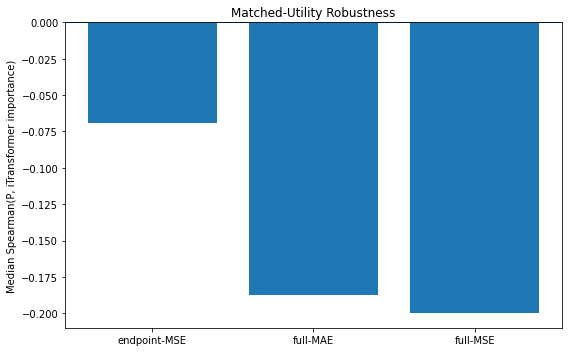

In [18]:
display(
    utility_summary.round(
        3
    )
)

display(
    pool_summary.round(
        3
    )
)

display(
    forecaster_summary[
        forecaster_summary[
            "metric"
        ]
        ==
        "endpoint"
    ].round(
        3
    )
)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(8, 5)
)

x = np.arange(
    len(utility_summary)
)

ax.bar(
    x,
    utility_summary[
        "median_rho_P_I"
    ],
)

ax.axhline(
    0.0,
    linewidth=1,
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    utility_summary[
        "utility"
    ]
)

ax.set_ylabel(
    "Median Spearman(P, iTransformer importance)"
)

ax.set_title(
    "Matched-Utility Robustness"
)

plt.tight_layout()
plt.show()


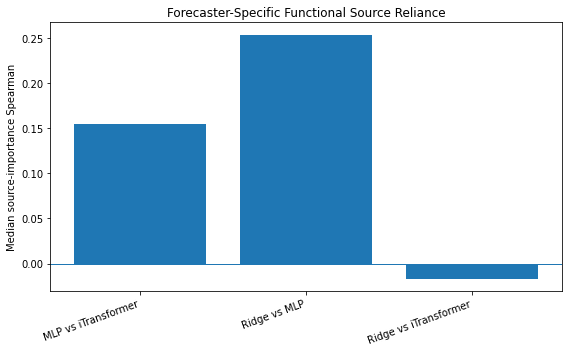

In [19]:
import matplotlib.pyplot as plt

plot = forecaster_summary[
    forecaster_summary[
        "metric"
    ]
    ==
    "endpoint"
].copy()

labels = (
    plot[
        "forecaster_A"
    ]
    +
    " vs "
    +
    plot[
        "forecaster_B"
    ]
)

x = np.arange(
    len(plot)
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    x,
    plot[
        "median_rho_importance"
    ],
)

ax.axhline(
    0.0,
    linewidth=1,
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    labels,
    rotation=20,
    ha="right",
)

ax.set_ylabel(
    "Median source-importance Spearman"
)

ax.set_title(
    "Forecaster-Specific Functional Source Reliance"
)

plt.tight_layout()
plt.show()


## 18. Automatic conservative interpretation


In [20]:
u = utility_summary.set_index(
    "utility"
)

p = pool_summary.set_index(
    "pool"
)

f_endpoint = forecaster_summary[
    forecaster_summary[
        "metric"
    ]
    ==
    "endpoint"
].copy()

endpoint_rho = float(
    u.loc[
        "endpoint-MSE",
        "median_rho_P_I",
    ]
)

full_mse_rho = float(
    u.loc[
        "full-MSE",
        "median_rho_P_I",
    ]
)

full_mae_rho = float(
    u.loc[
        "full-MAE",
        "median_rho_P_I",
    ]
)

base_rho = float(
    p.loc[
        "BaseOnly",
        "median_rho_endpoint",
    ]
)

ext_rho = float(
    p.loc[
        "Extended",
        "median_rho_endpoint",
    ]
)

def pair_rho(A, B):
    hit = f_endpoint[
        (
            f_endpoint[
                "forecaster_A"
            ]
            ==
            A
        )
        &
        (
            f_endpoint[
                "forecaster_B"
            ]
            ==
            B
        )
    ]

    if len(hit) != 1:
        return np.nan

    return float(
        hit.iloc[
            0
        ][
            "median_rho_importance"
        ]
    )

ridge_mlp = pair_rho(
    "Ridge",
    "MLP",
)

ridge_itr = pair_rho(
    "Ridge",
    "iTransformer",
)

mlp_itr = pair_rho(
    "MLP",
    "iTransformer",
)

print(
    "="
    *
    92
)

print(
    "FINAL ROBUSTNESS INTERPRETATION"
)

print(
    "="
    *
    92
)

print(
    "\nMatched utility P-I median Spearman:"
)

print(
    f"  endpoint MSE : {endpoint_rho:+.3f}"
)

print(
    f"  full MSE     : {full_mse_rho:+.3f}"
)

print(
    f"  full MAE     : {full_mae_rho:+.3f}"
)

print(
    "\nCandidate pool:"
)

print(
    f"  BaseOnly     : {base_rho:+.3f}"
)

print(
    f"  Extended     : {ext_rho:+.3f}"
)

print(
    "\nForecaster-specific endpoint importance:"
)

print(
    f"  Ridge vs MLP          : {ridge_mlp:+.3f}"
)

print(
    f"  Ridge vs iTransformer : {ridge_itr:+.3f}"
)

print(
    f"  MLP vs iTransformer   : {mlp_itr:+.3f}"
)

print(
    "\nWording constraint:"
)

print(
    "Do NOT claim: 'predictive relevance is model-dependent.'"
)

print(
    "Use: 'functional source reliance is forecaster-dependent' "
    "or 'controlled source utility does not necessarily transfer to "
    "a separately trained neural forecaster.'"
)


FINAL ROBUSTNESS INTERPRETATION

Matched utility P-I median Spearman:
  endpoint MSE : -0.069
  full MSE     : -0.200
  full MAE     : -0.187

Candidate pool:
  BaseOnly     : -0.087
  Extended     : -0.069

Forecaster-specific endpoint importance:
  Ridge vs MLP          : +0.254
  Ridge vs iTransformer : -0.017
  MLP vs iTransformer   : +0.155

Wording constraint:
Do NOT claim: 'predictive relevance is model-dependent.'
Use: 'functional source reliance is forecaster-dependent' or 'controlled source utility does not necessarily transfer to a separately trained neural forecaster.'


# 19. Paper interpretation

This section implements robustness and reliability checks for predictive utility and functional reliance under the fixed protocols reported in the paper.
